### **What are the most demanded skills for the top 3 most popular data roles?**
---
**Methodology**
1. Clean-up skill column
2. Calculate skill count based on `job_title_short`
3. Calculate skill percentage
4. Plot final findings

In [2]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [3]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [6]:
df_India = df[(df['job_country'] == 'India')]

In [7]:
df_skills = df_India.explode('job_skills')
df_skills[['job_title','job_skills']]

,job_title,job_skills
16,Big Data Engineer,powershell
16,Big Data Engineer,python
16,Big Data Engineer,sql
16,Big Data Engineer,mysql
16,Big Data Engineer,sql server
...,...,...
785716,Application Support Analyst,c#
785716,Application Support Analyst,sql
785718,Senior Performance QA Analyst,NaN
785740,AWS System Analyst,aws


In [9]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
type(df_skills_count )

pandas.Series

In [12]:
# Ensure df_skills_count has proper columns after reset
# If it was a Series, reset_index(name=...) would work, but handle DataFrame case robustly
df_skills_count = df_skills_count.reset_index()
if len(df_skills_count.columns) == 2:
    df_skills_count.columns = ['skill', 'skill_count']
# Sort and reset integer index
df_skills_count = df_skills_count.sort_values(by='skill_count', ascending=False).reset_index(drop=True)

df_skills_count

,index,job_skills,job_title_short,skill_count
0,1374,sql,Data Engineer,12993
1,1088,python,Data Engineer,11568
2,1089,python,Data Scientist,9248
3,1327,spark,Data Engineer,7157
4,103,aws,Data Engineer,6993
...,...,...,...,...
1684,34,angular.js,Data Scientist,1
1685,49,arch,Business Analyst,1
1686,787,mlpack,Data Engineer,1
1687,1679,yarn,Senior Data Scientist,1


In [16]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles


['Data Analyst', 'Data Engineer', 'Data Scientist']

Text(0.5, 0.98, 'Counts of Top Skills in Job Postings')

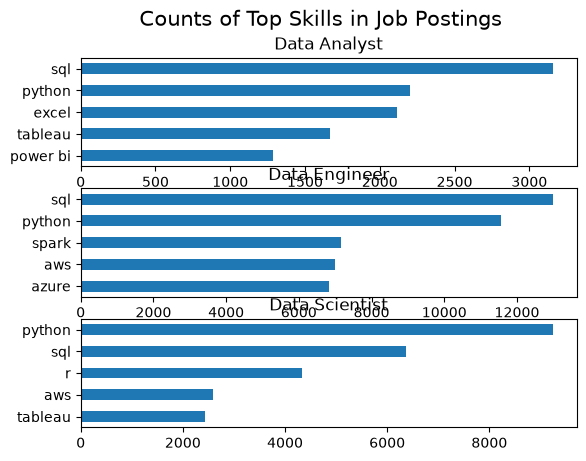

In [25]:
fig, ax = plt.subplots(len(job_titles), 1)
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)

In [20]:
df_job_title_count = df_India['job_title_short'].value_counts().reset_index(name='jobs_total')

In [22]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_perc['skill_percentage'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100
df_skills_perc

,index,job_skills,job_title_short,skill_count,jobs_total,skill_percentage
0,1374,sql,Data Engineer,12993,19062,68.161788
1,1088,python,Data Engineer,11568,19062,60.686182
2,1089,python,Data Scientist,9248,13279,69.643798
3,1327,spark,Data Engineer,7157,19062,37.545903
4,103,aws,Data Engineer,6993,19062,36.685552
...,...,...,...,...,...,...
1684,34,angular.js,Data Scientist,1,13279,0.007531
1685,49,arch,Business Analyst,1,1887,0.052994
1686,787,mlpack,Data Engineer,1,19062,0.005246
1687,1679,yarn,Senior Data Scientist,1,2486,0.040225


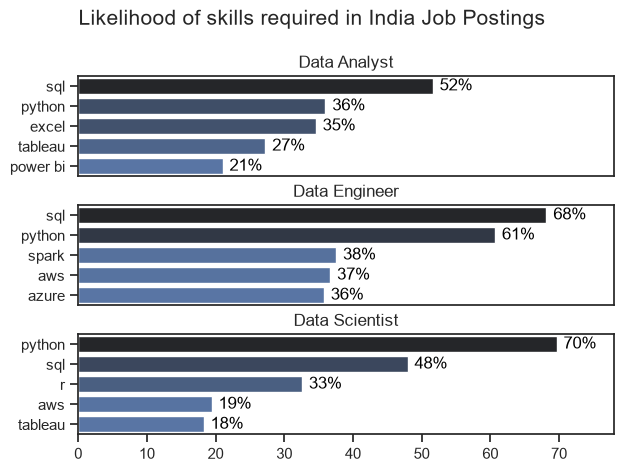

In [31]:
fig, ax = plt.subplots(len(job_titles), 1)
sns.set_theme(style='ticks')
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 78)  # Set x-axis limits to 0-78 for percentage

    for n, v in enumerate(df_plot['skill_percentage']):
        ax[i].text(v + 1, n, f"{v:.0f}%", color='black', va='center')
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

fig.suptitle('Likelihood of skills required in India Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5)